# Лабораторная работа: Спайковые нейронные сети

# Теоретическая часть

## 1. Суть нейроморфных вычислений и спайковых нейронных сетей

Нейроморфные вычисления — это парадигма, направленная на создание вычислительных систем, архитектура и принципы работы которых вдохновлены биологическим мозгом. В отличие от классических нейронных сетей, которые оперируют непрерывными значениями активаций (например, вещественными числами), спайковые нейронные сети (Spiking Neural Networks, SNN) используют **дискретные события во времени** — спайки (или потенциалы действия).

Основная цель нейроморфных систем — достичь высокой **энергоэффективности** и способности эффективно обрабатывать **временно́зависимые данные** (аудио, видео, сенсорные потоки), что критически важно для задач встраиваемого ИИ, робототехники и интерфейсов мозг-компьютер.


## 2. Модель нейрона LIF (Leaky Integrate-and-Fire)

Модель LIF является одной из самых распространенных и вычислительно эффективных моделей спайкового нейрона. Она описывает динамику мембранного потенциала $V(t)$.

Уравнение мембранного потенциала:

$$
\tau_m \frac{dV(t)}{dt} = -(V(t) - V_{rest}) + R_m I(t)
$$

где:
- $V(t)$ — мембранный потенциал в момент времени $t$,
- $\tau_m = R_m C_m$ — постоянная времени мембраны (произведение сопротивления $R_m$ и емкости $C_m$),
- $V_{rest}$ — потенциал покоя,
- $R_m$ — мембранное сопротивление,
- $I(t)$ — суммарный входной ток (от синапсов).

При достижении порогового потенциала $V_{th}$ нейрон генерирует спайк, и его потенциал сбрасывается до потенциала покоя $V_{rest}$ на период рефрактерности $\tau_{ref}$:

$$
\text{if } V(t) \geq V_{th} \text{, then:} \\
V(t) \rightarrow V_{rest} \\
\text{Запрет на срабатывание на время } \tau_{ref}
$$

## 3. Спайк-тайм-зависимая пластичность (STDP)

STDP — это биоинспирированное правило обучения, которое модифицирует силу синаптической связи (вес $w$) на основе временной корреляции между спайками пресинаптического и постсинаптического нейронов.

Формально, изменение веса $\Delta w$ определяется так:

$$
\Delta w =
\begin{cases}
A_{+} \cdot \exp\left(-\frac{\Delta t}{\tau_{+}}\right), & \text{если } \Delta t > 0 \text{ (пре-спайк до пост-спайка)} \\
-A_{-} \cdot \exp\left(-\frac{|\Delta t|}{\tau_{-}}\right), & \text{если } \Delta t < 0 \text{ (пре-спайк после пост-спайка)}
\end{cases}
$$

где:
- $\Delta t = t_{post} - t_{pre}$ — разница во времени между постсинаптическим и пресинаптическим спайками,
- $A_{+}, A_{-}$ — амплитуды усиления и ослабления связи,
- $\tau_{+}, \tau_{-}$ — временные константы для потенциации и депрессии.

STDP реализует принцип Хебба: *"Neurons that fire together, wire together"* (Нейроны, которые возбуждаются вместе, связываются вместе).

## Практическая часть

В данной работе вам предлагается реализовать и исследовать простую спайковую нейронную сеть на основе модели LIF с обучением по правилу STDP. Вы должны:

1.  Реализовать модель LIF-нейрона и исследовать его отклик на различные входные токи.
2.  Создать сеть из нескольких LIF-нейронов (например, входной слой, скрытый слой) и визуализировать распространение спайковой активности.
3.  Реализовать правило обучения STDP для синаптических связей.
4.  Обучить сеть на простой задаче (например, ассоциации паттернов) или классификации простых спайковых последовательностей.
5.  Проанализировать динамику весов, итоговую активность сети и эффективность обучения.

### Испорты

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset


# Параметры симуляции
num_steps = 100          # количество временных шагов для одного образца
batch_size = 32          # размер мини-пакета
input_size = 100         # 10x10 пикселей
hidden_size = 0          # однослойная сеть (без скрытого слоя)
output_size = 3          # классы: линия, круг, треугольник
dt = 0.1                 # шаг по времени (мс)

### Смоделировать динамику LIF-нейрона. Реализовать модель нейрона с утечкой и интеграцией (Leaky Integrate-and-Fire), изучить его реакцию на различные входные токи.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Callable
import random
import uuid

@dataclass
class LIFNeuron:
    tau_m: float = 20.0 # Постоянная времени мембраны (скорость утечки)
    v_rest: float = -70.0 # Потенциал покоя
    v_thresh: float = -55.0 # Порог срабатывания спайка
    v_reset: float = -75.0 # Потенциал сброса после спайка
    r_m: float = 15.0 # Мембранное сопротивление
    tau_ref: float = 5.0 # Длительность рефрактерного периода
    id: int = 0

    def __post_init__(self):
        '''Инициализирует состояние: устанавливает потенциал покоя, 
        сбрасывает историю спайков и трассировку напряжения'''
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times = []
        self.v_trace = []

    def reset(self):
        '''Полностью сбрасывает нейрон к исходному 
        состоянию (используется в начале каждой эпохи обучения)'''
        self.v = self.v_rest
        self.refractory_until = 0.0
        self.spike_times = []
        self.v_trace = []

    def step(self, I_inj: float, dt: float, t: float) -> bool:
        '''Выполняет один шаг симуляции: обновляет мембранный потенциал по формуле LIF, 
        проверяет порог, генерирует спайк. Возвращает True, если спайк произошёл'''
        if t < self.refractory_until:
            self.v = self.v_reset
            self.v_trace.append(self.v)
            return False

        dv = (-(self.v - self.v_rest) + self.r_m * I_inj) / self.tau_m
        self.v += dv * dt
        
        if self.v >= self.v_thresh:
            self.v_trace.append(self.v_thresh)
            self.v = self.v_reset
            self.refractory_until = t + self.tau_ref
            self.spike_times.append(t)
            return True
        else:
            self.v_trace.append(self.v)
            return False

def simulate_neuron(neuron: LIFNeuron, I_func: Callable[[float], float], 
                   T: float, dt: float) -> tuple:
    t_range = np.arange(0, T, dt)
    v_trace = []
    I_trace = []
    
    for t in t_range:
        I = I_func(t)
        neuron.step(I, dt, t)
        v_trace.append(neuron.v)
        I_trace.append(I)
    
    return t_range, np.array(v_trace), np.array(I_trace), neuron.spike_times

### Функции входного тока

In [14]:
def make_step_current(I_on: float, t_start: float, t_end: float):
    return lambda t: I_on if t_start <= t <= t_end else 0.0

def make_ramp_current(I_max: float, t_start: float, t_end: float):
    return lambda t: I_max * (t - t_start) / (t_end - t_start) if t_start <= t <= t_end else 0.0

def make_sinusoidal_current(I_amp: float, freq_hz: float, I_offset: float = 0.0):
    return lambda t: I_offset + I_amp * np.sin(2 * np.pi * freq_hz * t / 1000.0)

def make_noisy_current(I_mean: float, noise_std: float):
    return lambda t: I_mean + np.random.normal(0, noise_std)

def make_pulse_train(I_amp: float, pulse_width: float, period: float):
    return lambda t: I_amp if (t % period) < pulse_width else 0.0
def plot_detailed_response(t, v, I, spikes, title: str):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    
    ax1.plot(t, I, 'g-', label='I_inj')
    ax1.set_ylabel('Ток (нА)')
    ax1.grid(True)
    ax1.set_title(title)
    
    ax2.plot(t, v, 'b-', label='V_m')
    ax2.axhline(y=-55.0, color='r', linestyle='--', label='Порог')
    ax2.axhline(y=-70.0, color='gray', linestyle=':', label='Покой')
    ax2.set_ylabel('Потенциал (мВ)')
    ax2.legend()
    ax2.grid(True)
    
    if spikes:
        ax3.eventplot(spikes, colors='k', linewidths=2)
    ax3.set_ylabel('Спайки')
    ax3.set_yticks([])
    ax3.set_xlabel('Время (мс)')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

### Реакция на разные формы тока

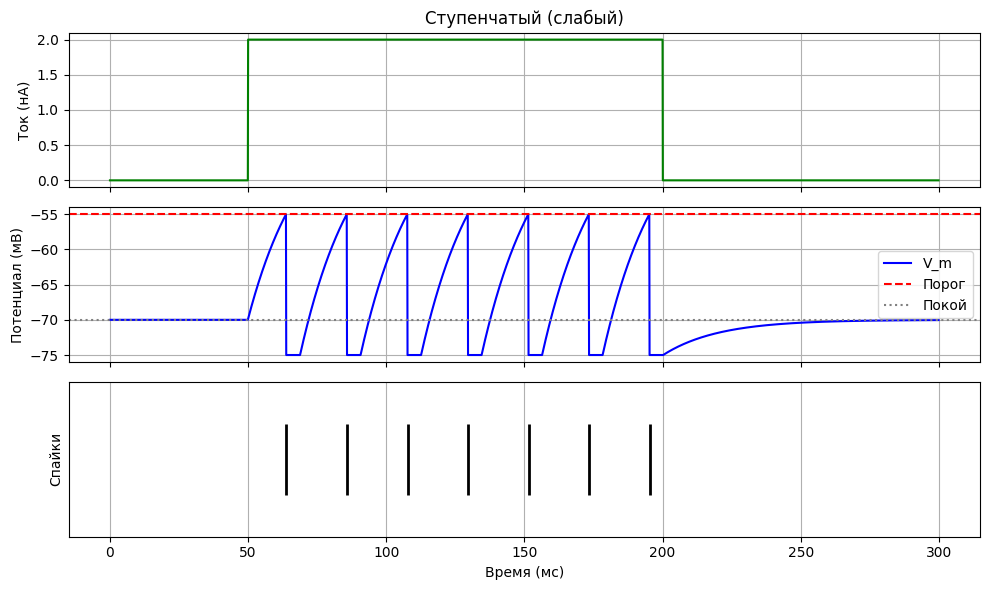

Ступенчатый (слабый): 7 спайков


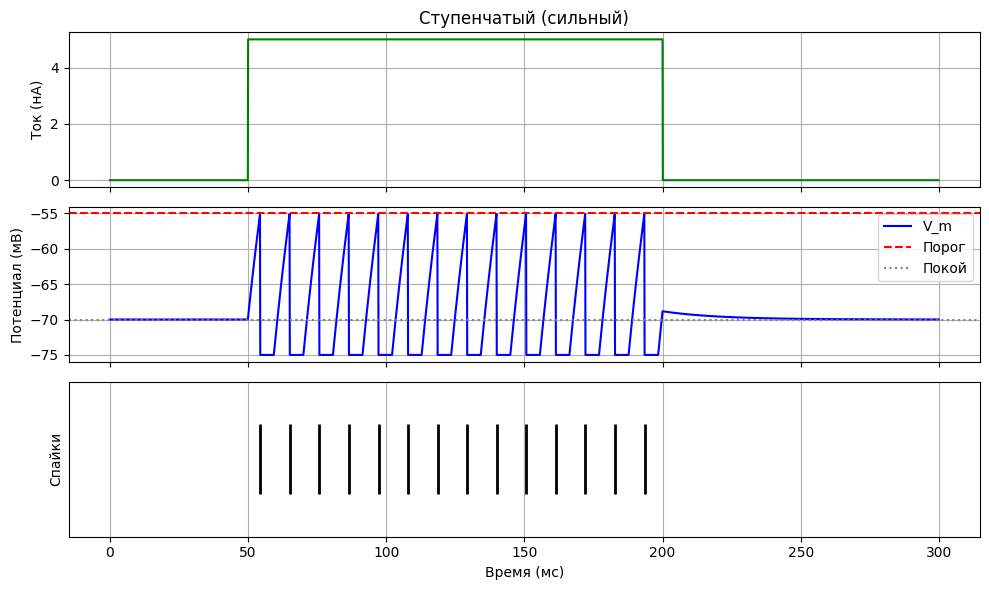

Ступенчатый (сильный): 14 спайков


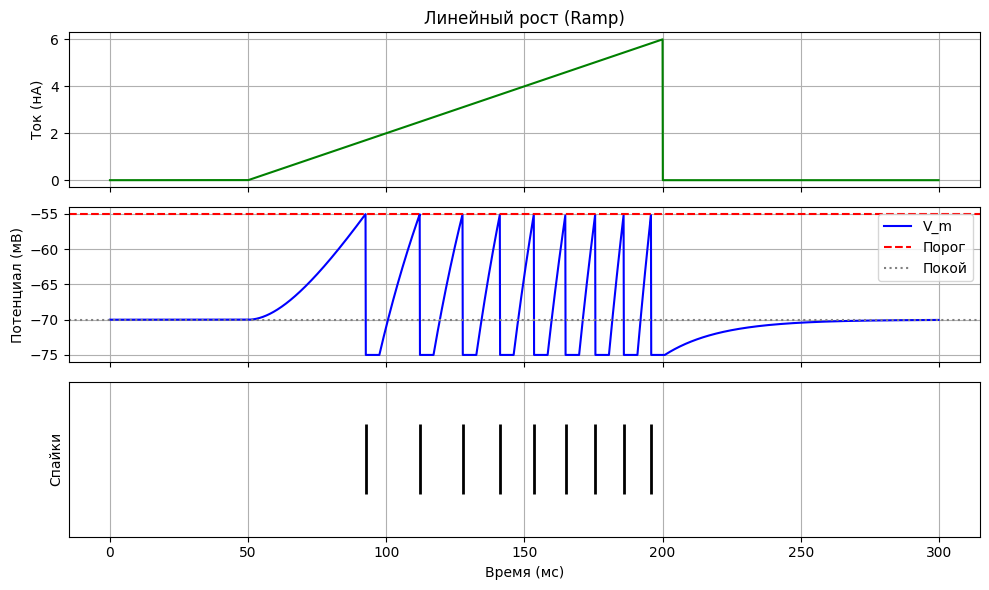

Линейный рост (Ramp): 9 спайков


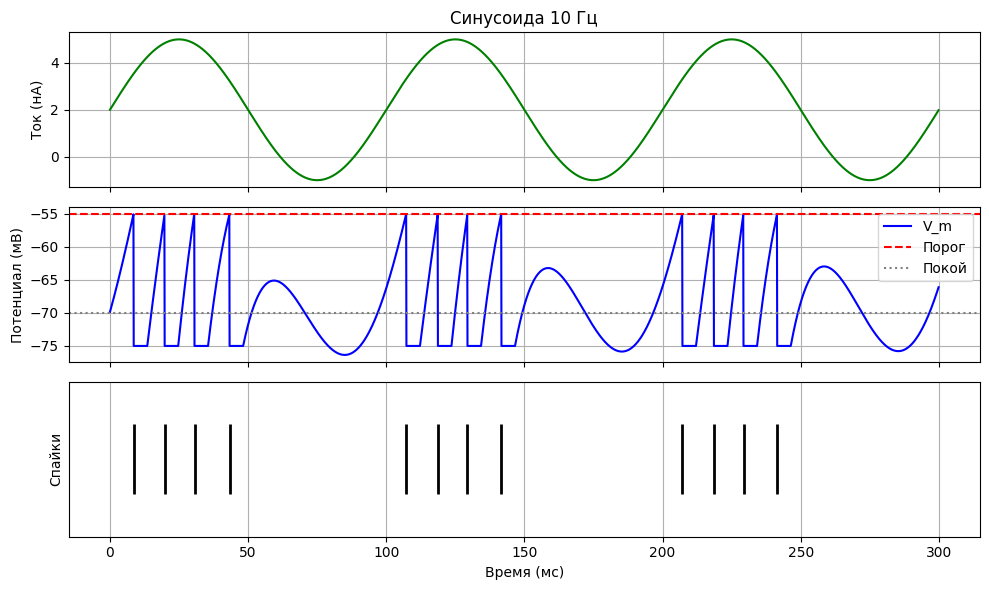

Синусоида 10 Гц: 12 спайков


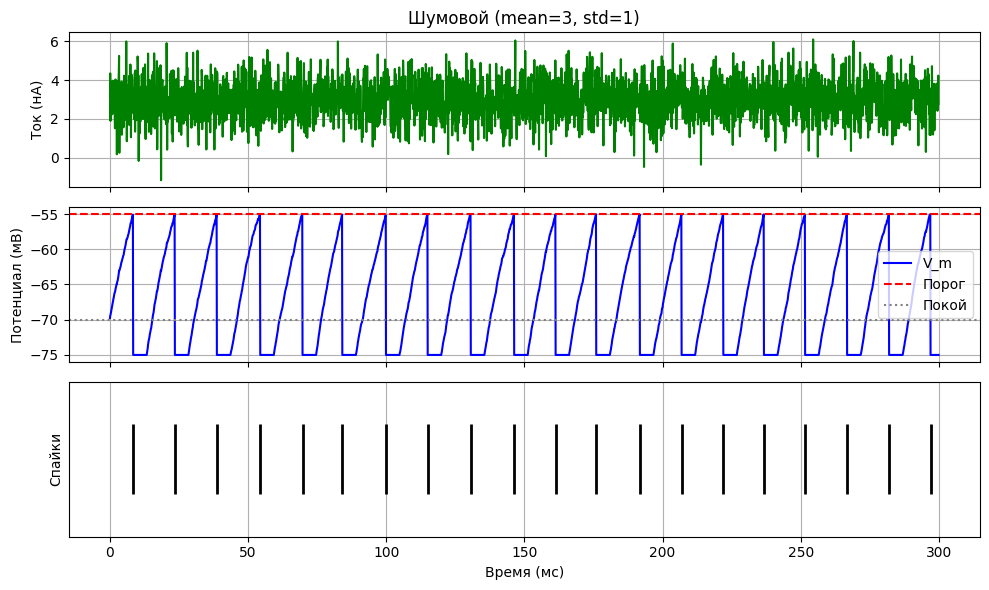

Шумовой (mean=3, std=1): 20 спайков


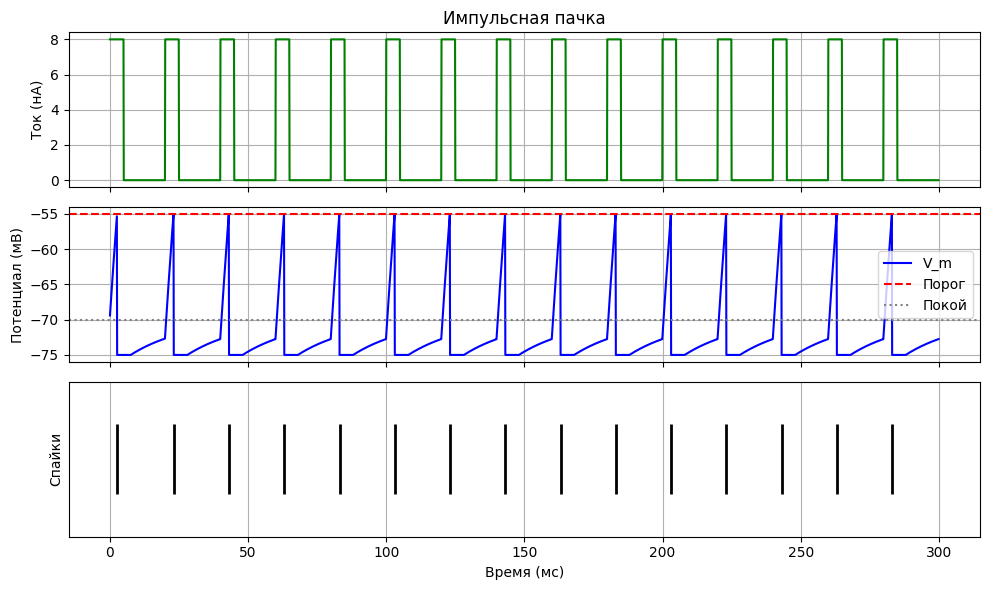

Импульсная пачка: 15 спайков


In [15]:
dt, T = 0.1, 300
configs = [
    ("Ступенчатый (слабый)", make_step_current(2.0, 50, 200)),
    ("Ступенчатый (сильный)", make_step_current(5.0, 50, 200)),
    ("Линейный рост (Ramp)", make_ramp_current(6.0, 50, 200)),
    ("Синусоида 10 Гц", make_sinusoidal_current(3.0, 10, I_offset=2.0)),
    ("Шумовой (mean=3, std=1)", make_noisy_current(3.0, 1.0)),
    ("Импульсная пачка", make_pulse_train(8.0, pulse_width=5, period=20)),
]

for name, I_func in configs:
    neuron = LIFNeuron()
    t, v, I, spikes = simulate_neuron(neuron, I_func, T, dt)
    plot_detailed_response(t, v, I, spikes, name)
    print(f"{name}: {len(spikes)} спайков")

Создаем синтетический набор данных "Две луны" (Two Moons):

Генерируем 1000 точек, образующих две полумесяца — это классическая задача бинарной классификации с нелинейной разделяющей границей

Добавляем небольшой шум (параметр noise=0.2), чтобы задача была не слишком простой

Стандартизируем признаки — приводим их к среднему 0 и дисперсии 1, что важно для стабильного обучения

Разбиваем данные на обучающую (80%) и тестовую (20%) выборки

Преобразуем в тензоры PyTorch и создаем DataLoader для пакетной обработки по 32 примера

Визуализируем данные, чтобы увидеть форму двух полумесяцев — синий и красный классы

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)  # нормализуем
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразуем в тензоры
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# Для классической сети создадим DataLoader
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Определение классической нейронной сети

Создаем эталонную модель для сравнения:

- Простая полносвязная сеть с двумя слоями

- Первый слой: от 2 входных признаков к 128 скрытым нейронам

- Функция активации: ReLU (выпрямитель) — стандартный выбор для классических сетей

- Второй слой: от 128 нейронов к 2 выходным (по одному на каждый класс)

- На выходе получаем логиты (не нормализованные вероятности), которые будут подаваться в функцию потерь CrossEntropyLoss

In [26]:
class ClassicNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Определение суррогатного градиента для спайков

Это ключевая техническая хитрость для обучения спайковых сетей:

Проблема: функция генерации спайка (пороговое сравнение) недифференцируема — её производная везде ноль, кроме точки разрыва, где она бесконечна

Решение: используем суррогатный градиент — при обратном распространении заменяем настоящую производную на аппроксимацию

В прямом проходе: если потенциал >= порога, возвращаем 1, иначе 0

В обратном проходе: возвращаем градиент сигмоиды (σ(x)*(1-σ(x))), который плавный и имеет ненулевые значения

Это позволяет обучать SNN стандартным методом обратного распространения ошибки

In [27]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input, threshold):
        ctx.save_for_backward(input)
        ctx.threshold = threshold
        out = (input >= threshold).float()
        return out

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        threshold = ctx.threshold
        # суррогатный градиент: производная сигмоиды с масштабом
        grad_input = grad_output * torch.sigmoid(input - threshold) * (1 - torch.sigmoid(input - threshold))
        return grad_input, None

def spike_function(v, threshold):
    return SurrogateSpike.apply(v, threshold)

Определение LIF слоя (Leaky Integrate-and-Fire)

Реализуем слой спайковых нейронов с мембранным потенциалом:

In [28]:
class LIFLayer(nn.Module):
    def __init__(self, input_size, output_size, beta=0.9, threshold=1.0, reset=0.0):
        super().__init__()
        self.input_size = input_size
        self.output_size = output_size
        self.beta = beta
        self.threshold = threshold
        self.reset = reset
        self.fc = nn.Linear(input_size, output_size)

    def forward(self, input_spikes):
        # input_spikes: (batch, input_size, time_steps)
        batch_size, _, time_steps = input_spikes.shape
        # Инициализируем состояние: мембранный потенциал (batch, output_size)
        v = torch.zeros(batch_size, self.output_size, device=input_spikes.device)
        # Выходные спайки
        output_spikes = []
        for t in range(time_steps):
            # Входной ток через синапсы: линейная комбинация входных спайков
            # входные спайки в момент t: (batch, input_size)
            x_t = input_spikes[:, :, t]
            current = self.fc(x_t)  # (batch, output_size)
            # Обновление потенциала
            v = self.beta * v + current
            # Генерация спайков
            spike = spike_function(v, self.threshold)
            # Сброс потенциала (вычитание порога при спайке)
            v = v - spike * self.threshold
            output_spikes.append(spike.unsqueeze(-1))
        # Объединяем по времени: (batch, output_size, time_steps)
        output_spikes = torch.cat(output_spikes, dim=-1)
        return output_spikes


Определение полной спайковой нейронной сети (SNN)

Собираем полную архитектуру SNN:

Два LIF слоя: скрытый (128 нейронов) и выходной (2 нейрона)

Входное кодирование (rate coding):

Преобразуем действительные числа в вероятности спайков

Нормализуем признаки в диапазон [0,1] (после стандартизации значения примерно от -2 до 2)

Для каждого из T=100 временных шагов генерируем спайк по Бернулли с этой вероятностью

Прямой проход:

Кодируем входные признаки в последовательность спайков (размер: batch×2×100)

Пропускаем через скрытый LIF слой (получаем batch×128×100)

Пропускаем через выходной LIF слой (получаем batch×2×100)

Суммируем спайки по времени — получаем "активность" каждого выходного нейрона

Чем больше спайков сгенерировал нейрон, тем выше вероятность соответствующего класса

Функции для обучения

Создаем функции обучения для обеих сетей:

Для классической сети: стандартный цикл обучения с CrossEntropyLoss и оптимизатором Adam

Для спайковой сети: аналогичный цикл, но на вход подаются признаки, которые внутри модели кодируются в спайки

В обоих случаях выводим потери и точность после каждой эпохи, чтобы отслеживать прогресс

In [29]:
class SNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2, T=100, beta=0.9, threshold=1.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.T = T
        self.beta = beta
        self.threshold = threshold
        self.hidden_layer = LIFLayer(input_size, hidden_size, beta=beta, threshold=threshold)
        self.output_layer = LIFLayer(hidden_size, output_size, beta=beta, threshold=threshold)

    def encode_input(self, x):
        # x: (batch, input_size) - признаки
        # Преобразуем в вероятности спайков в диапазоне [0,1]
        # Нормализуем: значения примерно в [-2,2] после стандартизации, поэтому сдвигаем и масштабируем
        p = torch.clamp((x + 2) / 4, 0, 1)  # (batch, input_size)
        # Генерируем случайные спайки для каждого временного шага
        # Расширяем для T: (batch, input_size, T)
        p = p.unsqueeze(-1).expand(-1, -1, self.T)
        # Бернулли
        spikes = torch.bernoulli(p)
        return spikes

    def forward(self, x):
        # Кодируем вход в спайки
        input_spikes = self.encode_input(x)  # (batch, input_size, T)
        # Прямой проход по слоям
        hidden_spikes = self.hidden_layer(input_spikes)  # (batch, hidden_size, T)
        output_spikes = self.output_layer(hidden_spikes)  # (batch, output_size, T)
        # Для классификации суммируем спайки по времени (batch, output_size)
        spike_counts = output_spikes.sum(dim=-1)
        return spike_counts
    
def train_classic(model, train_loader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
        acc = correct / total
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Acc: {acc:.4f}")
    return model

def train_snn(model, train_loader, epochs=20, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)  # spike_counts (batch, output_size)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
        acc = correct / total
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Acc: {acc:.4f}")
    return model

Реализуем добавление шума для проверки устойчивости:

Для классической сети: добавляем гауссов шум к входным признакам

Шум нормально распределенный с нулевым средним и заданным стандартным отклонением

Чем больше σ, тем сильнее искажаются признаки

Для спайковой сети: добавляем случайные шумовые спайки

С вероятностью noise_prob на каждом входном канале генерируется лишний спайк

Объединяем сигнальные и шумовые спайки через логическое ИЛИ (если хоть один источник дал спайк, на входе 1)

Это имитирует реальные шумы в спайковых сенсорах

In [30]:
def test_classic_with_noise(model, test_loader, noise_std):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            # Добавляем гауссов шум
            noisy_data = data + torch.randn_like(data) * noise_std
            output = model(noisy_data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    return correct / total

def test_snn_with_noise(model, test_loader, noise_prob):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            # Кодируем сигнальные спайки
            p_signal = torch.clamp((data + 2) / 4, 0, 1)
            p_signal = p_signal.unsqueeze(-1).expand(-1, -1, model.T)
            signal_spikes = torch.bernoulli(p_signal)
            # Генерируем шумовые спайки с вероятностью noise_prob
            noise_spikes = torch.bernoulli(torch.full_like(signal_spikes, noise_prob))
            # Объединяем (логическое ИЛИ) - если хоть один источник дал спайк
            input_spikes = (signal_spikes + noise_spikes).clamp(0, 1)
            # Прямой проход, подменяя encode_input
            # Вместо вызова forward, делаем прямой проход вручную, используя слои
            hidden_spikes = model.hidden_layer(input_spikes)
            output_spikes = model.output_layer(hidden_spikes)
            spike_counts = output_spikes.sum(dim=-1)
            pred = spike_counts.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
    return correct / total

In [31]:
# Параметры
hidden_size = 128
epochs = 20
lr = 0.001
T = 100
beta = 0.9
threshold = 1.0

Training classic network...
Epoch 1, Loss: 0.5162, Acc: 0.8287
Epoch 2, Loss: 0.3339, Acc: 0.8662
Epoch 3, Loss: 0.2890, Acc: 0.8738
Epoch 4, Loss: 0.2735, Acc: 0.8775
Epoch 5, Loss: 0.2656, Acc: 0.8862
Epoch 6, Loss: 0.2549, Acc: 0.8862
Epoch 7, Loss: 0.2455, Acc: 0.8925
Epoch 8, Loss: 0.2365, Acc: 0.8962
Epoch 9, Loss: 0.2264, Acc: 0.9000
Epoch 10, Loss: 0.2165, Acc: 0.9087
Epoch 11, Loss: 0.2064, Acc: 0.9150
Epoch 12, Loss: 0.1969, Acc: 0.9237
Epoch 13, Loss: 0.1880, Acc: 0.9275
Epoch 14, Loss: 0.1791, Acc: 0.9325
Epoch 15, Loss: 0.1707, Acc: 0.9400
Epoch 16, Loss: 0.1633, Acc: 0.9437
Epoch 17, Loss: 0.1561, Acc: 0.9437
Epoch 18, Loss: 0.1497, Acc: 0.9487
Epoch 19, Loss: 0.1439, Acc: 0.9537
Epoch 20, Loss: 0.1379, Acc: 0.9563

Training SNN...
Epoch 1, Loss: 0.7113, Acc: 0.6012
Epoch 2, Loss: 0.3704, Acc: 0.8450
Epoch 3, Loss: 0.3476, Acc: 0.8550
Epoch 4, Loss: 0.3432, Acc: 0.8300
Epoch 5, Loss: 0.3293, Acc: 0.8438
Epoch 6, Loss: 0.3680, Acc: 0.8325
Epoch 7, Loss: 0.3140, Acc: 0.8550

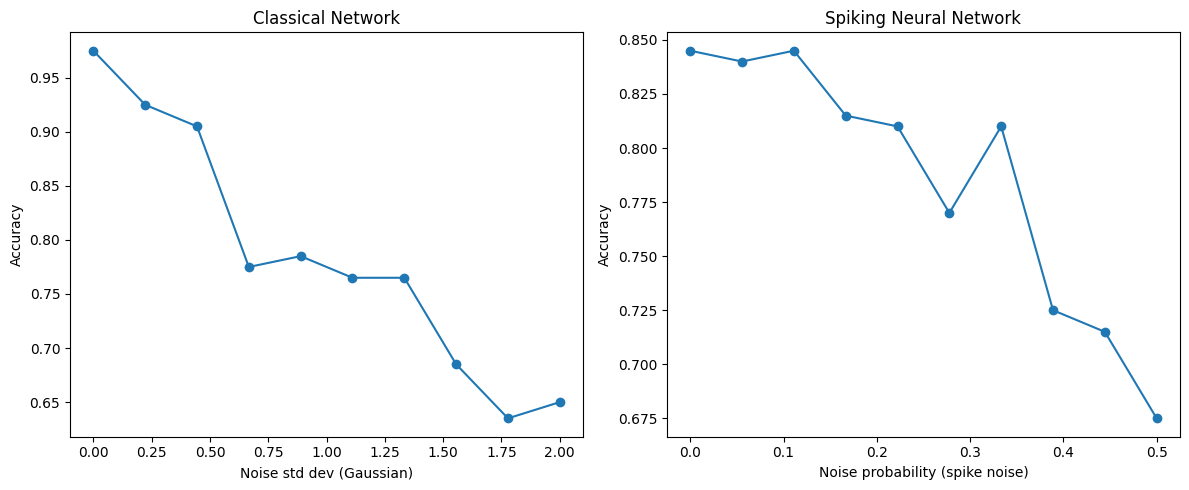

In [32]:
# Инициализация моделей
classic_model = ClassicNet(input_size=2, hidden_size=hidden_size, output_size=2)
snn_model = SNN(input_size=2, hidden_size=hidden_size, output_size=2, T=T, beta=beta, threshold=threshold)

# Обучение
print("Training classic network...")
train_classic(classic_model, train_loader, epochs, lr)

print("\nTraining SNN...")
train_snn(snn_model, train_loader, epochs, lr)

# Тестирование с разными уровнями шума
noise_levels_classic = np.linspace(0, 2, 10)  # стандартное отклонение шума
noise_levels_snn = np.linspace(0, 0.5, 10)   # вероятность шумового спайка

acc_classic = []
acc_snn = []

for noise_std in noise_levels_classic:
    acc = test_classic_with_noise(classic_model, test_loader, noise_std)
    acc_classic.append(acc)
    print(f"Classic noise std {noise_std:.2f}: accuracy {acc:.4f}")

for noise_prob in noise_levels_snn:
    acc = test_snn_with_noise(snn_model, test_loader, noise_prob)
    acc_snn.append(acc)
    print(f"SNN noise prob {noise_prob:.2f}: accuracy {acc:.4f}")

# Построение графиков
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(noise_levels_classic, acc_classic, marker='o')
plt.xlabel('Noise std dev (Gaussian)')
plt.ylabel('Accuracy')
plt.title('Classical Network')

plt.subplot(1,2,2)
plt.plot(noise_levels_snn, acc_snn, marker='o')
plt.xlabel('Noise probability (spike noise)')
plt.ylabel('Accuracy')
plt.title('Spiking Neural Network')
plt.tight_layout()
plt.show()